## ==========================================================
# SMARTCART CUSTOMER SEGMENTATION SYSTEM
#  Unsupervised Machine Learning
#
# Objective:
# Segment customers into meaningful clusters
# using K-Means Clustering.
# Dataset:
# SmartCart Customer Dataset
# Algorithm:
# K-Means Clustering
# Evaluation:
# Elbow Method
==========================================================

Import Libraries

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

Load Dataset

In [14]:
df = pd.read_csv("smartcart_customers.csv")

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


Dataset Overview

In [15]:
print("Rows and Columns")

print(df.shape)

print("\nColumns")

print(df.columns)

print("\nData Types")

print(df.dtypes)

Rows and Columns
(2240, 22)

Columns
Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

Data Types
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases  

Missing Values

In [16]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


Statistical Summary

In [17]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.009375,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.096391,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000


Correlation Heatmap

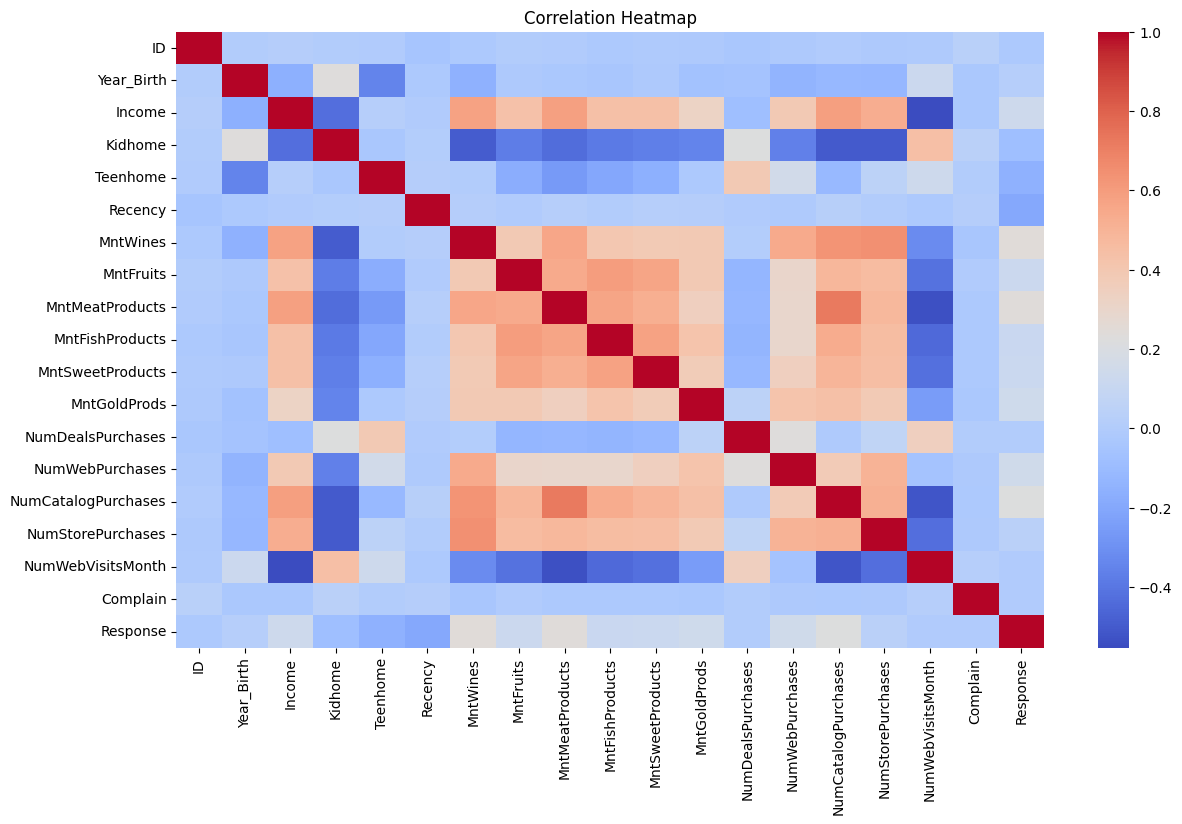

In [18]:
plt.figure(figsize=(14,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

Data Preprocessing

In [19]:
encoder = LabelEncoder()

categorical_columns = [
    "Education",
    "Marital_Status"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

print("Encoding Completed")

Encoding Completed


Remove Unnecessary Columns

In [20]:
df = df.drop(
    ["ID","Dt_Customer"],
    axis=1,
    errors='ignore'
)

df.dropna(subset=['Income'], inplace=True)

df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,1957,2,4,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,1
1,1954,2,4,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0
2,1965,2,5,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0
3,1984,2,5,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0
4,1981,4,3,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0


After dropping rows with null values and making sure the data is clean, the next step is to re-run the cells that were impacted by this fix to observe the results.

In [ ]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

print("Scaling Completed")

In [ ]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(
        kmeans.inertia_
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    scaled_data
)

df["Cluster"] = clusters

print("Clusters Created Successfully")

In [ ]:
df["Cluster"].value_counts()

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Income"],
    y=df["MntWines"],
    hue=df["Cluster"],
    palette="Set2"
)

plt.title(
    "Customer Segmentation"
)

plt.show()

In [ ]:
cluster_summary = df.groupby(
    "Cluster"
).mean()

cluster_summary

Feature Scaling

In [21]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

print("Scaling Completed")

Scaling Completed


Elbow Method

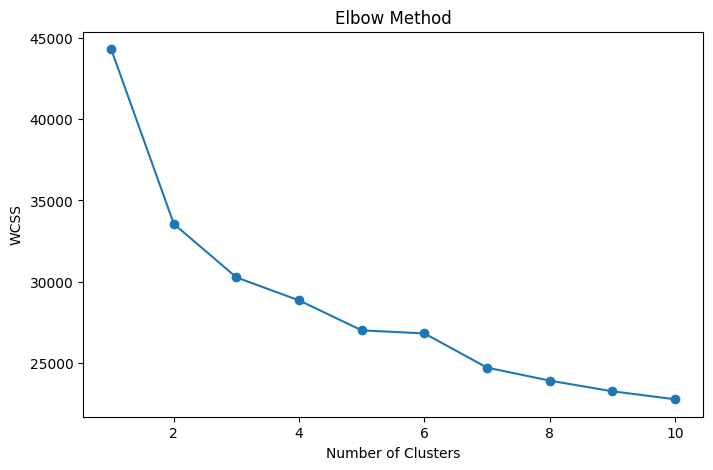

In [22]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(
        kmeans.inertia_
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

Apply K-Means

In [23]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    scaled_data
)

df["Cluster"] = clusters

print("Clusters Created Successfully")

Clusters Created Successfully


Cluster Distribution

In [24]:
df["Cluster"].value_counts()

,count
Cluster,
3,577
2,567
0,539
1,533


Cluster Visualization

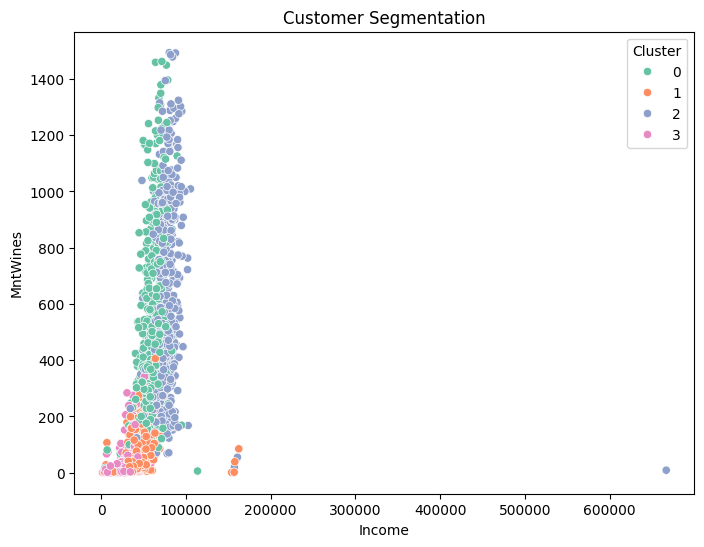

In [25]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Income"],
    y=df["MntWines"],
    hue=df["Cluster"],
    palette="Set2"
)

plt.title(
    "Customer Segmentation"
)

plt.show()

Cluster Analysis

In [26]:
cluster_summary = df.groupby(
    "Cluster"
).mean()

cluster_summary

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
Cluster,,,,,,,,,,,,,,,,,,,,
0,1964.575139,2.673469,3.662338,59705.192950,0.178108,0.925788,47.821892,522.807050,23.235622,149.085343,31.009276,24.489796,65.673469,3.660482,6.636364,3.330241,8.109462,5.671614,0.009276,0.128015
1,1963.101313,2.560976,3.772983,42884.251407,0.682927,0.971857,50.395872,72.369606,4.446529,26.255159,6.418386,4.440901,14.827392,2.478424,2.363977,0.744841,3.636023,5.851782,0.011257,0.052533
2,1968.569665,2.336861,3.791887,76954.645503,0.044092,0.155203,49.402116,592.202822,69.962963,458.079365,101.666667,71.361552,76.860670,1.319224,5.114638,6.035273,8.343915,2.813051,0.005291,0.287478
3,1978.315425,2.034662,3.677643,29650.294627,0.856153,0.025997,48.464471,34.554593,6.658579,27.696707,9.748700,6.701906,18.277296,1.918544,2.280763,0.528596,3.145581,6.960139,0.012132,0.126516


Business Insights

In [27]:
print("""

Cluster 0 :
High Spending Customers
→ Premium Customers

Cluster 1 :
Low Spending Customers
→ Budget Customers

Cluster 2 :
Frequent Buyers
→ Loyal Customers

Cluster 3 :
Low Activity Users
→ Churn Risk Customers

""")



Cluster 0 :
High Spending Customers
→ Premium Customers

Cluster 1 :
Low Spending Customers
→ Budget Customers

Cluster 2 :
Frequent Buyers
→ Loyal Customers

Cluster 3 :
Low Activity Users
→ Churn Risk Customers




Conclusion

In [28]:
print("""

SmartCart Customer Segmentation System

✔ Dataset analyzed successfully

✔ Data preprocessed successfully

✔ K-Means Clustering applied

✔ Optimal clusters identified

✔ Customer segments created

✔ Useful for targeted marketing

✔ Useful for customer retention

""")



SmartCart Customer Segmentation System

✔ Dataset analyzed successfully

✔ Data preprocessed successfully

✔ K-Means Clustering applied

✔ Optimal clusters identified

✔ Customer segments created

✔ Useful for targeted marketing

✔ Useful for customer retention


